In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import numpy as np
from scipy.stats import mannwhitneyu


In [2]:
# Read in data
df = pd.read_csv('../data/Radius_100_patient_id_edited.csv', index_col=0)
df.head()

,Entry ID,Cell ID,Cell Type,Neg,CD8_T,CD4_T,Endothelial,Stromal,HSPC,UMAP_1,UMAP_2,Leiden_Group,PID,tp,pid_tp
0,7142785f-c543-4768-9a8c-3153238275a9,5,CD8_T,14.514444,2.689997,0.000000,0.508647,0.473824,2.789986,-2.888258,-2.316883,18,P08,C1,P08_C1
1,7142785f-c543-4768-9a8c-3153238275a9,8,CD8_T,14.988450,2.622916,0.000000,0.522399,0.407936,3.250461,-2.888675,-2.320224,18,P08,C1,P08_C1
2,7142785f-c543-4768-9a8c-3153238275a9,95,CD8_T,15.129865,2.792207,0.000000,0.760356,0.000000,0.379367,-3.360949,-2.057606,13,P08,C1,P08_C1
3,7142785f-c543-4768-9a8c-3153238275a9,148,CD8_T,17.181909,3.216538,0.000000,1.220715,0.000000,0.426072,-4.089715,-1.429748,13,P08,C1,P08_C1
4,7142785f-c543-4768-9a8c-3153238275a9,153,CD8_T,4.583257,1.000000,0.710311,0.000000,3.059426,2.314174,-5.261656,8.218327,8,P08,C1,P08_C1


In [3]:
# Read in samples used to examine changes in cellular abundance from C1 to C7 to C12
samples = ['P01_Day_0', 'P01_Day_336','P02_Day_0', 'P03_Day_0',
'P03_Day_168', 'P03_Day_336','P04_Day_0', 'P04_Day_168',
'P04_Day_336', 'P05_Day_0', 'P05_Day_336', 'P07_Day_0',
'P07_Day_336', 'P08_Day_0', 'P08_Day_140', 'P08_Day_168',
'P11_Day_0', 'P11_Day_336', 'P12_Day_336','P13_Day_0',
'P14_Day_0', 'P14_Prog', 'P16_Day_0', 'P17_Day_0',
'P17_Day_168', 'P18_Day_0', 'P18_Day_168', 'P18_Prog',
'P19_Day_0', 'P21_Day_0', 'P22_Day_0', 'P24_Day_0', 'P25_Day_0', 'P25_Day_168', 'P28_Day_0']

tp_dict = {'0' : 'C1', '140': 'C6', '168' : 'C7', '336' : 'C12', 'Prog' : 'Prog'}

samples1 = [] # Rename 
for i in samples:
    x = i.split('_')
    samples1.append(x[0] + '_' + tp_dict[x[-1]])

In [4]:
# Print the samples in the dataframe which are not included in Michaels analysis
list2 = []
for i in df['pid_tp'].unique():
    list2.append(i)

for i in samples1:
    if i not in list2:
        print(i)


P08_C6
P17_C7


In [5]:
# Add clinical information to the dataframe
outcomes = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx')
outcomes['Outcome_C6_revised_Vid'] = outcomes['Outcome_C6_revised_Vid'].replace('non-responder_2', 'Non-responder').replace('responder_1', 'Responder')
outcomes['Outcome_C12_CC486'] = outcomes['Outcome_C12_CC486'].replace('non-responder_2', 'Non-responder').replace('responder_1', 'Responder')

outcomes_6 = dict(zip(outcomes['PID'], outcomes['Outcome_C6_revised_Vid']))
outcomes_12 = dict(zip(outcomes['PID'], outcomes['Outcome_C12_CC486']))
diagnosis = dict(zip(outcomes['PID'], outcomes['Diagnosis']))

outcomes['PID'] = outcomes['PID'].astype(str)

df['diagnosis'] = df['PID'].map(diagnosis)
df['outcomes_6'] = df['PID'].map(outcomes_6)
df['outcomes_12'] = df['PID'].map(outcomes_12)

In [7]:
df['pid_tp'].unique()

array(['P08_C1', 'P08_C7', 'P24_C1', 'P19_C1', 'P12_C12', 'P04_C1',
       'P04_C7', 'P04_C12', 'P03_C1', 'P03_C7', 'P03_C12', 'P16_C1',
       'P14_C1', 'P14_Prog', 'P05_C1', 'P05_C12', 'P02_C1', 'P01_C1',
       'P01_C12', 'P11_C1', 'P11_C12', 'P28_C1', 'P07_C1', 'P07_C12',
       'P17_C1', 'P18_C1', 'P18_C7', 'P18_Prog', 'P22_C1', 'P25_C1',
       'P25_C7', 'P13_C1', 'P21_C1'], dtype=object)

In [8]:
# Delete P02 C1D1 timepoint as it has few cells. This patient 
df = df.loc[df['pid_tp'] != 'P02_C1', :]


In [12]:
df

,Entry ID,Cell ID,Cell Type,Neg,CD8_T,CD4_T,Endothelial,Stromal,HSPC,UMAP_1,UMAP_2,Leiden_Group,PID,tp,pid_tp,diagnosis,outcomes_6,outcomes_12
0,7142785f-c543-4768-9a8c-3153238275a9,5,CD8_T,14.514444,2.689997,0.000000,0.508647,0.473824,2.789986,-2.888258,-2.316883,18,P08,C1,P08_C1,MDS,Non-responder,Non-responder
1,7142785f-c543-4768-9a8c-3153238275a9,8,CD8_T,14.988450,2.622916,0.000000,0.522399,0.407936,3.250461,-2.888675,-2.320224,18,P08,C1,P08_C1,MDS,Non-responder,Non-responder
2,7142785f-c543-4768-9a8c-3153238275a9,95,CD8_T,15.129865,2.792207,0.000000,0.760356,0.000000,0.379367,-3.360949,-2.057606,13,P08,C1,P08_C1,MDS,Non-responder,Non-responder
3,7142785f-c543-4768-9a8c-3153238275a9,148,CD8_T,17.181909,3.216538,0.000000,1.220715,0.000000,0.426072,-4.089715,-1.429748,13,P08,C1,P08_C1,MDS,Non-responder,Non-responder
4,7142785f-c543-4768-9a8c-3153238275a9,153,CD8_T,4.583257,1.000000,0.710311,0.000000,3.059426,2.314174,-5.261656,8.218327,8,P08,C1,P08_C1,MDS,Non-responder,Non-responder
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046937,33277076-7c0c-455a-90c9-f2dc9968c39d,34671,HSPC,8.025754,0.000000,0.000000,1.920477,0.000000,2.824589,-2.831910,3.443634,11,P21,C1,P21_C1,MDS,Responder,Non-responder
1046938,33277076-7c0c-455a-90c9-f2dc9968c39d,34691,HSPC,9.053919,0.000000,0.000000,1.877296,0.000000,2.880094,-2.119202,3.072119,5,P21,C1,P21_C1,MDS,Responder,Non-responder
1046939,33277076-7c0c-455a-90c9-f2dc9968c39d,34702,HSPC,22.670587,0.000000,1.499274,1.339609,0.000000,4.012542,-1.227022,-0.825529,29,P21,C1,P21_C1,MDS,Responder,Non-responder
1046940,33277076-7c0c-455a-90c9-f2dc9968c39d,34703,HSPC,22.991540,0.000000,1.984655,1.308631,0.000000,3.779023,-1.237542,-0.868958,29,P21,C1,P21_C1,MDS,Responder,Non-responder


In [17]:
# Correctly annotate each sample (annotate patients with only a C1 based on the response at C7). Some patients 
# who have C1 and C12 measurements switched clinical responses between C1 and C7 and C12. Therefore, if the patient
# has a C1 and a C12 only match the patient to a C12 measurement

patients_not_c1 = [] # Create a list of patients which have a timepoint which is not C1
for i, e in zip(df['tp'], df['PID']):
    if i != 'C1':
        patients_not_c1.append(e)
patients_not_c1 = list(set(patients_not_c1))   
patients_not_c1

correct_response_dict = {} # Create a dictionary which details the correct clinical outcome for each patient

for i in df['PID'].unique():
    a = df.loc[df['PID'] == i, :]
    if len(a['tp'].unique()) >= 2:
        b = a['tp'].unique()[1]
        if (i in patients_not_c1) and (b == 'C7'):
            correct_response_dict[i] = outcomes_6[i]
        if (i in patients_not_c1) and (b == 'C12'):
            correct_response_dict[i] = outcomes_12[i]
        if (i in patients_not_c1) and (b == 'Prog'):
            correct_response_dict[i] = outcomes_12[i]
    elif i not in patients_not_c1:
        correct_response_dict[i] = outcomes_6[i]

In [19]:
# Create a dictionary which details the number of cells in each cluster for each patient
c1_dict = {}
for i in df['Leiden_Group'].unique():
    a = df.loc[(df['Leiden_Group'] == i) & (df['tp'] == 'C1'), :]
    
    for patient in a['PID'].unique():
        b = a.loc[(a['PID'] == patient), :]
        
        # Initialize nested structure
        if patient not in c1_dict:
            c1_dict[patient] = {}
        if i not in c1_dict[patient]:
            c1_dict[patient][i] = {}
        if b.shape[0] != 0:
            c1_dict[patient][i] = b.shape[0]
        

In [20]:
# Turn the dictionary into a dataframe
c1_df = pd.DataFrame(c1_dict)
c1_df = c1_df.fillna(0)

# Create a df which details the percent of cells
c1_df_pct = c1_df.div(c1_df.sum(axis=0), axis=1) * 100
c1_df_pct.head()


,P08,P24,P19,P04,P03,P16,P14,P05,P01,P11,P28,P07,P17,P18,P22,P25,P13,P21
18,1.299907,2.809415,3.854693,0.240779,5.065346,5.367246,3.892427,3.906623,3.934684,4.719021,1.983122,3.821195,4.484904,1.053331,1.816665,2.064251,1.378119,0.293138
13,3.044519,2.602717,4.508449,0.556801,4.345293,4.736394,2.441614,4.605158,5.508558,3.825563,1.645570,1.756663,4.252446,2.173118,0.735935,1.656264,2.528658,0.159893
8,6.299174,0.168734,4.372764,0.948067,2.901024,0.632521,4.246285,3.996179,0.432815,1.446552,0.590717,0.063385,0.807338,4.229939,4.588006,0.426900,3.738200,0.059960
39,0.664614,1.598751,3.959541,0.270876,2.784483,3.850198,0.743100,5.136523,1.691914,1.113278,0.696203,0.890405,1.174817,0.980229,0.721105,1.475237,0.295010,0.299800
29,2.252847,1.303467,3.867028,0.243789,1.872971,5.235401,1.486200,5.198217,1.455833,3.676653,1.624473,2.146026,2.854916,3.631833,1.041802,1.418497,1.074680,0.406396


In [21]:
# Group columns by their group
grouped_cols = defaultdict(list)
for col in c1_df.columns:
    if col in correct_response_dict.keys():
        group = correct_response_dict[col]
        grouped_cols[group].append(col)
grouped_cols

defaultdict(list,
            {'Non-responder': ['P08',
              'P24',
              'P16',
              'P14',
              'P05',
              'P28',
              'P22',
              'P25'],
             'Responder': ['P19',
              'P04',
              'P03',
              'P01',
              'P11',
              'P07',
              'P17',
              'P18',
              'P13',
              'P21']})

In [22]:
# Read in p-values for the diagnosis samples
p_val = pd.read_excel('../data/2026_02_14_p_values_from_jake.xlsx', sheet_name= 'Responder_Non-responder_diagnos')
p_val = p_val.iloc[:59, :]
p_val.head()


from statsmodels.stats.multitest import multipletests

p_values = p_val['p_value'].to_list()

reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

print(p_adjusted)

p_val['p_adjusted'] = p_adjusted
p_val

[0.56345    0.56345    0.865884   0.865884   0.865884   0.865884
 0.865884   0.865884   0.865884   0.865884   0.865884   0.865884
 0.865884   0.865884   0.865884   0.865884   0.865884   0.865884
 0.865884   0.865884   0.865884   0.865884   0.865884   0.865884
 0.865884   0.90164643 0.90164643 0.90164643 1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.        ]


,Cluster,p_value,p_adjusted
0,43,0.0146,0.563450
1,32,0.0191,0.563450
2,27,0.0457,0.865884
3,26,0.0789,0.865884
4,39,0.1056,0.865884
5,1,0.1174,0.865884
6,35,0.1306,0.865884
7,23,0.1339,0.865884
8,15,0.1376,0.865884
9,33,0.1587,0.865884


In [27]:
# Read in a df which maps a cluster to a cell type (i.e. dominant focal cell type of each cell type)
cluster_cell = pd.read_excel('../data/2026_03_10_all_clusters_annotated.xlsx')#2026_03_02_Cluster_to_celltype.xlsx')
cluster_cell_dict = dict(zip(cluster_cell['Cluster'], cluster_cell['Cell_Type']))
cluster_cell_dict

# Create a dictionary to match each focal cell type to a color
color = pd.read_excel('../data/cell_type_colors.xlsx', sheet_name= '2026_02_23')

new_row = pd.DataFrame({'Cell_Type': ['Endo'], 'Color': ['#FFD94AFF']})
color = pd.concat([color, new_row], ignore_index=True)


color_dict = dict(zip(color['Cell_Type'], color['Color']))

# Create a dictionary to match a cluster to a color
cluster_color_dict = {}
for x, y in cluster_cell_dict.items():
    cluster_color_dict[x] = color_dict[y]

del color_dict
del cluster_cell_dict

cluster_color_dict

{0: '#B85A0DFF',
 1: '#3CB7CCFF',
 2: '#3CB7CCFF',
 3: '#3CB7CCFF',
 4: 'Grey',
 5: 'Grey',
 6: '#3CB7CCFF',
 7: '#3CB7CCFF',
 8: '#32A251FF',
 9: 'Grey',
 10: '#3CB7CCFF',
 11: '#FFD94AFF',
 12: '#FF7F0FFF',
 13: '#FF7F0FFF',
 14: '#3CB7CCFF',
 15: '#3CB7CCFF',
 16: '#3CB7CCFF',
 17: '#FF7F0FFF',
 18: '#FF7F0FFF',
 19: '#3CB7CCFF',
 20: '#B85A0DFF',
 21: '#3CB7CCFF',
 22: '#3CB7CCFF',
 23: '#3CB7CCFF',
 24: '#3CB7CCFF',
 25: 'Grey',
 26: '#3CB7CCFF',
 27: '#B85A0DFF',
 28: '#3CB7CCFF',
 29: 'Grey',
 30: '#32A251FF',
 31: 'Grey',
 32: '#32A251FF',
 33: '#FF7F0FFF',
 34: '#FFD94AFF',
 35: '#3CB7CCFF',
 36: '#32A251FF',
 37: '#3CB7CCFF',
 38: '#32A251FF',
 39: '#FF7F0FFF',
 40: '#32A251FF',
 41: '#B85A0DFF',
 42: '#FF7F0FFF',
 43: '#B85A0DFF',
 44: '#FF7F0FFF',
 45: '#FFD94AFF',
 46: '#FF7F0FFF',
 47: '#B85A0DFF',
 48: '#32A251FF',
 49: '#3CB7CCFF',
 50: '#FF7F0FFF',
 51: '#3CB7CCFF',
 52: '#FFD94AFF',
 53: '#3CB7CCFF',
 54: '#3CB7CCFF',
 55: '#32A251FF',
 56: '#FF7F0FFF',
 57: '#32A251F

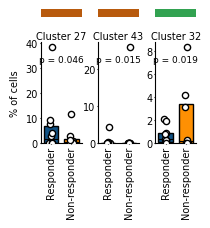

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42


to_plot = [27, 43, 32]
colors = {'Responder': '#115284', 'Non-responder': '#fe9003'}

fig, axes = plt.subplots(ncols=3, figsize=(1.809, 1.5))

for i, cluster in enumerate(to_plot):
    ax = axes[i]
    
    labels = list(colors.keys())
    group_data = {}
    
    for label in labels:
        patient_ids = grouped_cols[label]  # directly get list of IDs
        # Filter to patients present in the dataframe columns
        valid_ids = [p for p in patient_ids if p in c1_df_pct.columns]
        group_data[label] = c1_df_pct.loc[cluster, valid_ids].values.astype(float)

    # Compute mean ± SEM
    means = [group_data[l].mean() for l in labels]
    #sd  =[group_data[l].std() for l in labels]
    x_pos = np.arange(len(labels))

    # # Draw bars
    # ax.bar(x_pos, means, #yerr=sd,
    #        width=0.9,
    #        color=[colors[l] for l in labels],
    #        capsize=4, alpha=1.0, error_kw=dict(elinewidth=1.5))
    bp = ax.boxplot([group_data[l] for l in labels], positions=x_pos, widths=0.7,
                    patch_artist=True, showfliers=False)
    for patch, label in zip(bp['boxes'], labels):
        patch.set_facecolor(colors[label])
        patch.set_alpha(1.0)
    for element in ['whiskers', 'caps']:
        for item in bp[element]:
            item.set_linewidth(0)
    for item in bp['medians']:
        item.set_color('black')
        item.set_linewidth(0.8)

    
    # Overlay individual patient points with jitter
    for j, label in enumerate(labels):
        vals = group_data[label]
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(j + jitter, vals,
                   color='white', edgecolors= 'black',
                   s=20, linewidths=1.0, zorder=5)

    p_val1 = p_val.loc[p_val['Cluster'] == cluster, 'p_value'].values[0]
    ax.text(0.5, 0.87, f'p = {p_val1:.3f}',
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=6.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_title(f'Cluster {cluster}', fontsize=7, y = 0.95)
    ax.set_ylabel('% of cells' if i == 0 else '', fontsize = 7)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(bottom = 0)
    ax.tick_params(pad = 1, length = 1, labelsize = 7)
    ax.add_patch(
    plt.Rectangle(
        (0, 1.25),      # x, y (in axis coordinates)
        1,              # width (full axis width)
        0.08,           # height of color bar
        transform=ax.transAxes,
        clip_on=False,
        facecolor=cluster_color_dict[cluster],
        edgecolor='none'
    )
)
plt.subplots_adjust(left=0.12, right=0.98, top=0.92, bottom=0.25, wspace=0.4)
plt.show()
fig.savefig('../results/diagnosis_responders_non_responders.pdf', dpi = 600)


In [33]:
# Create a dictionary which details the number of cells in each cluster for each patient at a response timepoint
response_dict = {}
for i in df['Leiden_Group'].unique():
    a = df.loc[(df['Leiden_Group'] == i) & (df['tp'] != 'C1'), :].copy()
    #a['pid_tp'] = a['PID'] + '_' + a['tp']
    for x in a['pid_tp'].unique():
        b = a.loc[a['pid_tp'] == x, :]
        if b.shape[0] != 0 and any(t in x for t in ['C7', 'C12', 'Prog']):
            if x not in response_dict:
                response_dict[x] = {}
            response_dict[x][i] = b.shape[0]
            

In [34]:
# Turn the dictionary into a dataframe
response_df = pd.DataFrame(response_dict)
response_df = response_df.fillna(0)

# Create a df which details the percent of cells
response_df_pct = response_df.div(response_df.sum(axis=0), axis=1) * 100
response_df_pct.head()


,P08_C7,P12_C12,P04_C7,P04_C12,P03_C7,P03_C12,P14_Prog,P05_C12,P01_C12,P11_C12,P07_C12,P18_C7,P18_Prog,P25_C7
18,4.968009,4.641215,2.765018,0.036415,4.296736,2.413120,2.509653,6.994329,2.435268,2.705458,5.941266,0.770501,0.244058,0.146901
13,6.260193,5.852027,3.679258,0.182965,1.816024,2.965826,1.930502,1.323251,4.325202,4.281681,4.014599,1.981288,1.307455,0.350695
8,14.464935,6.775812,9.851492,0.382805,0.771513,4.819016,5.791506,2.835539,13.491799,5.583438,0.186726,0.000000,2.039630,0.937452
39,4.008280,2.902327,0.798287,0.031974,0.937685,1.159598,0.193050,2.079395,0.978270,0.870452,1.358004,0.440286,0.185949,0.118880
29,3.456279,2.336631,2.225394,0.020428,2.373887,1.390795,1.061776,1.701323,2.847390,2.109473,2.300119,0.550358,0.761230,0.078970


In [35]:
# Read in p-values
p_val = pd.read_excel('../data/2026_02_14_p_values_from_jake.xlsx', sheet_name= 'Responder_Non-responder-respons')
p_val = p_val.iloc[:59, :]
p_val.head()

# try correcting for multiple comparisons
from statsmodels.stats.multitest import multipletests

p_values = p_val['p_value'].to_list()

reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

print(p_adjusted)

p_val['p_adjusted'] = p_adjusted

[0.01737222 0.0110625  0.16501562 0.16919118 0.00726154 0.07746129
 0.07407778 0.0318087  0.00196667 0.01737222 0.6370525  0.23976944
 0.00196667 0.00505714 0.01101333 0.00726154 0.23976944 0.00236
 0.00726154 0.45324103 0.0318087  0.00726154 0.02781429 0.00726154
 0.07746129 0.00393333 0.01053571 0.29096316 0.73289512 0.0361375
 0.00196667 0.045076   0.9992     0.02478    0.16919118 0.07407778
 0.00726154 0.2765027  0.00236    0.07712143 0.9992     0.9992
 0.02018421 0.9992     0.07746129 0.9521125  0.75407619 0.9521125
 0.9992     0.9521125  0.9992     0.9521125  0.9521125  0.9992
 0.95363265 0.9992     0.955682   0.96540196 0.9521125 ]


In [36]:
clus = []
for x, y in zip(p_val['Cluster'], p_val['p_adjusted']):
    if y <= 0.05:
        clus.append(x)
clus

[0,
 1,
 4,
 7,
 8,
 9,
 12,
 13,
 14,
 15,
 17,
 18,
 20,
 21,
 22,
 23,
 25,
 26,
 29,
 30,
 31,
 33,
 36,
 38,
 42]

In [37]:
# Create a dictionary which maps each obesrvation to a clinical outcome
out_dict = {}
for i in response_df_pct.columns:
    x, y = i.split('_')
    if y == 'C7':
        out_dict[i] = outcomes_6[x]
    else:
        out_dict[i] = outcomes_12[x]

In [38]:
# Order the categories list to allow for easy plotting
order = ['CD8_T',
 'CD4_T', 'Stromal',
  'HSPC', 'Endothelial',
 'Endo', 'Mixed',]

cluster_dict1 = dict(zip(cluster_cell['Cluster'], cluster_cell['Cell_Type']))
cluster_dict1

list_ordered = []
for i in order:
    for x, y in cluster_dict1.items():
        if (y == i) and (x in clus):
            list_ordered.append(x)
            print(x, i)


12 CD8_T
13 CD8_T
17 CD8_T
18 CD8_T
33 CD8_T
42 CD8_T
0 CD4_T
20 CD4_T
8 Stromal
30 Stromal
36 Stromal
38 Stromal
1 HSPC
7 HSPC
14 HSPC
15 HSPC
21 HSPC
22 HSPC
23 HSPC
26 HSPC
4 Mixed
9 Mixed
25 Mixed
29 Mixed
31 Mixed


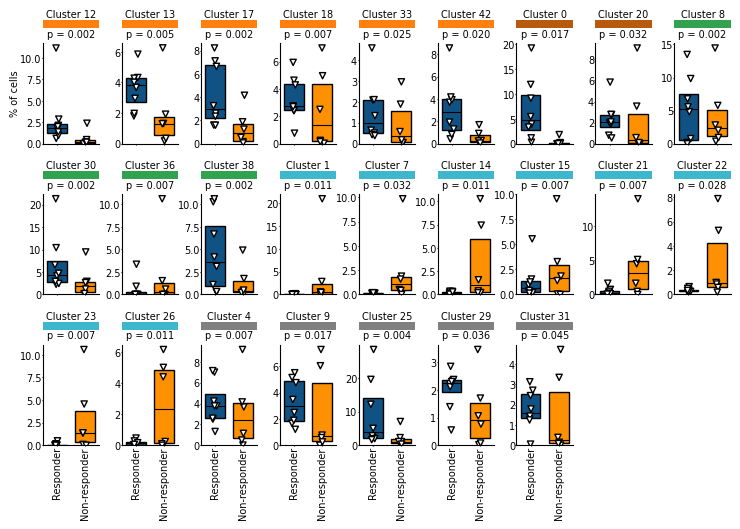

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

to_plot = list_ordered#[12, 30, 17, 38, 25, 23, 21, 0]

colors = {'Responder': '#115284', 'Non-responder': '#fe9003'}

disease_colors = {
    'MDS': 'white',
    'AML': 'white', 
    'CMML': 'white',
}

fig, axes = plt.subplots(nrows=3, ncols=9, figsize=(8, 6.7), sharex= True)

axes = axes.flatten()

for i, cluster in enumerate(to_plot):
    ax = axes[i]
    
    labels = list(colors.keys())
    group_data = {}
    
    for label in labels:
        patient_ids = [key for key, value in out_dict.items() if value == label]  # directly get list of IDs
        # Filter to patients present in the dataframe columns
        valid_ids = [p for p in patient_ids if p in response_df_pct.columns]
        group_data[label] = response_df_pct.loc[cluster, valid_ids].values.astype(float)

    # Compute mean
    means = [group_data[l].mean() for l in labels]
    
    x_pos = np.arange(len(labels))

    # Draw boxes
    bp = ax.boxplot([group_data[l] for l in labels], positions=x_pos, widths=0.7,
                    patch_artist=True, showfliers=False)
    for patch, label in zip(bp['boxes'], labels):
        patch.set_facecolor(colors[label])
        patch.set_alpha(1.0)
    for element in ['whiskers', 'caps']:
        for item in bp[element]:
            item.set_linewidth(0)
    for item in bp['medians']:
        item.set_color('black')
        item.set_linewidth(0.8)
        
    # Overlay individual patient points with jitter
    for j, label in enumerate(labels):
        patient_ids = [key for key, value in out_dict.items() if value == label]
        valid_ids = [p for p in patient_ids if p in response_df_pct.columns]
        vals = response_df_pct.loc[cluster, valid_ids].values.astype(float)
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        facecolors = [disease_colors.get(diagnosis.get(p.split('_')[0], ''), 'grey') for p in valid_ids]
        ax.scatter(j + jitter, vals,
                   facecolors=facecolors, edgecolors='black', marker = 'v',
                   s=20, linewidths=1.0, zorder=5)

    p_val1 = p_val.loc[p_val['Cluster'] == cluster, 'p_adjusted'].values[0]
    ax.text(0.5, 1.14, f'p = {p_val1:.3f}',
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=7)
    
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_title(f'Cluster {cluster}', fontsize=7, y = 1.175)
    ax.set_ylabel('% of cells' if i == 0 else '', fontsize = 7, labelpad = 0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(bottom = 0)
    ax.tick_params(pad = 0, length = 1, labelsize = 7)
    
    # Add cluster color bar above subplot
    cluster_color = cluster_color_dict[cluster]

    ax.add_patch(
    plt.Rectangle(
        (0, 1.15),      # x, y (in axis coordinates)
        1,              # width (full axis width)
        0.08,           # height of color bar
        transform=ax.transAxes,
        clip_on=False,
        facecolor=cluster_color,
        edgecolor='none'
    )
)
    # Turn off the last two axes which aren't used
    for ax in axes[len(to_plot):]:
        ax.set_visible(False)
plt.subplots_adjust(left=0.12, right=0.98, top=0.85, bottom=0.25, wspace=0.4, hspace=0.5)

fig.savefig('../results/response_responders_non_responders.pdf', dpi = 600)
